# Day 45 — Neurons, Perceptrons, MLPs & Backpropagation
- Understand biological inspiration and artificial neurons
- Build a neuron mathematically
- Understand perceptrons and logical computations
- See why a single perceptron cannot solve XOR
- Understand multilayer perceptrons (MLPs)
- Explore activation functions
- Understand forward propagation, loss, backpropagation, and gradient descent
- Build a small MLP with Keras and inspect its training


## 1. The Core Neural-Network Idea

An artificial neuron performs:

$$
z = XW + b
$$

and then applies an activation function:

$$
a = f(z)
$$

Where:

- **X** = inputs
- **W** = weights
- **b** = bias
- **z** = weighted sum
- **f** = activation function
- **a** = neuron output

### Mental model

**weighted inputs → sum + bias → activation → output**


In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

X = np.array([2.0, 3.0])
weights = np.array([0.5, 0.2])
bias = 0.1

z = np.dot(X, weights) + bias
output = max(0, z)  # ReLU

print("Inputs:", X)
print("Weights:", weights)
print("Bias:", bias)
print("Weighted sum z:", z)
print("ReLU output:", output)


Inputs: [2. 3.]
Weights: [0.5 0.2]
Bias: 0.1
Weighted sum z: 1.7000000000000002
ReLU output: 1.7000000000000002


## 2. Why Bias Matters

Without a bias:

$$
z = w_1x_1 + w_2x_2
$$

With a bias:

$$
z = w_1x_1 + w_2x_2 + b
$$

The bias lets the neuron shift its decision boundary instead of forcing it through the origin.


## 3. Logical Computations

A perceptron can represent simple linearly separable logical functions such as AND and OR.

For a binary threshold neuron:

$$
output =
\begin{cases}
1 & z \ge 0 \\
0 & z < 0
\end{cases}
$$


In [9]:
def step(z):
    return (z >= 0).astype(int)

# A simple AND-like neuron
X_logic = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

weights_and = np.array([1.0, 1.0])
bias_and = -1.5

z_and = X_logic @ weights_and + bias_and
y_and = step(z_and)

print("Inputs:")
print(X_logic)
print("\nOutputs:")
print(y_and)


Inputs:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Outputs:
[0 0 0 1]


## 4. The Perceptron

A perceptron is a simple artificial neuron using a threshold/step activation.

Conceptually:

```text
x1 ──× w1 ──┐
x2 ──× w2 ──┼──► weighted sum + bias ──► step ──► 0/1
x3 ──× w3 ──┘
```

A single perceptron creates a **linear decision boundary**.


## 5. XOR — The Perceptron Limitation

XOR:

| x1 | x2 | XOR |
|---:|---:|---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

The positive and negative examples cannot be separated by one straight line.

**Key lesson:** a single perceptron cannot solve XOR, but a multilayer network can.


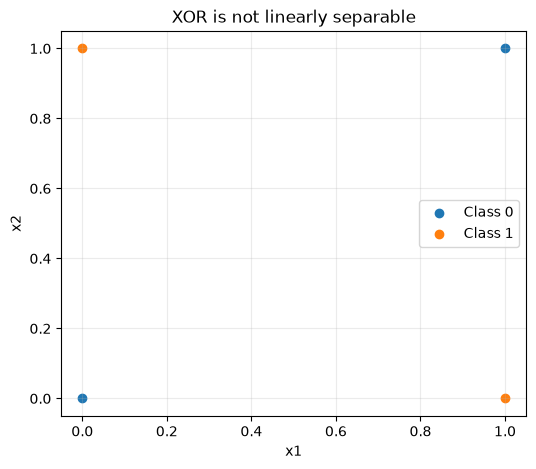

In [10]:
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_xor = np.array([0, 1, 1, 0])

plt.figure(figsize=(6, 5))
plt.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1], label="Class 0")
plt.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], label="Class 1")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("XOR is not linearly separable")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()


## 6. Activation Functions

Activation functions introduce nonlinearity.

Today we focus on:

- Step
- Sigmoid
- tanh
- ReLU

### ReLU

$$
ReLU(z) = max(0,z)
$$

### Sigmoid

$$
\sigma(z) = \frac{1}{1+e^{-z}}
$$

### tanh

$$
tanh(z)
$$


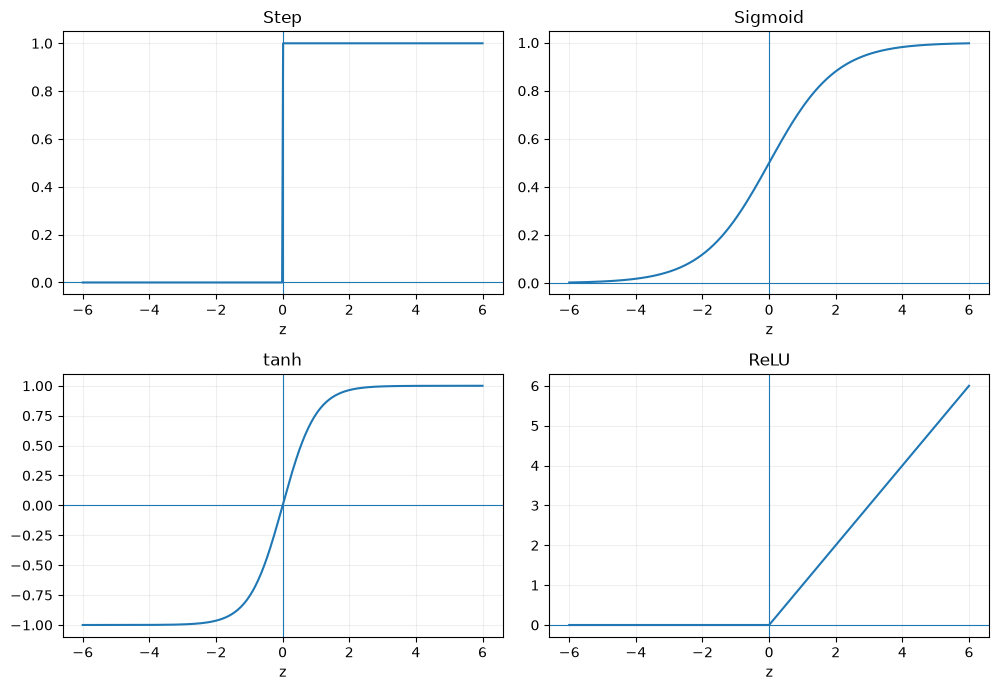

In [11]:
z_values = np.linspace(-6, 6, 400)

sigmoid = 1 / (1 + np.exp(-z_values))
tanh = np.tanh(z_values)
relu = np.maximum(0, z_values)
step_values = (z_values >= 0).astype(float)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

axes[0, 0].plot(z_values, step_values)
axes[0, 0].set_title("Step")

axes[0, 1].plot(z_values, sigmoid)
axes[0, 1].set_title("Sigmoid")

axes[1, 0].plot(z_values, tanh)
axes[1, 0].set_title("tanh")

axes[1, 1].plot(z_values, relu)
axes[1, 1].set_title("ReLU")

for ax in axes.ravel():
    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)
    ax.grid(True, alpha=0.2)
    ax.set_xlabel("z")

plt.tight_layout()
plt.show()


## 7. Why Nonlinearity Matters

If every layer only performed a linear transformation, stacking layers would still result in a linear transformation.

Activation functions such as ReLU allow an MLP to learn **nonlinear relationships**.

This is one of the fundamental reasons multilayer neural networks are much more expressive than a single perceptron.


## 8. Multilayer Perceptron (MLP)

An MLP typically contains:

```text
Input Layer
     ↓
Hidden Layer
     ↓
Hidden Layer
     ↓
Output Layer
```

A fully connected layer is commonly called a **Dense layer** in Keras.

Each neuron learns weights and a bias.


## 9. Forward Propagation

For each layer:

$$
z^{(l)} = W^{(l)}a^{(l-1)} + b^{(l)}
$$

Then:

$$
a^{(l)} = f(z^{(l)})
$$

Data flows from input toward output:

```text
Input → Hidden 1 → Hidden 2 → Output → Prediction
```

This is the **forward pass**.


## 10. Loss

After the forward pass, the prediction is compared with the target.

```text
Input
  ↓
Neural network
  ↓
Prediction
  ↓
Loss
  ↓
How wrong was the prediction?
```

Training attempts to minimize the loss.


## 11. Backpropagation

Backpropagation calculates how the loss changes with respect to the network parameters.

For a weight:

$$
\frac{\partial Loss}{\partial w}
$$

The chain rule allows gradients to be efficiently propagated backward through the network.

```text
Forward:
Input ─────────────────────────► Prediction ─► Loss

Backward:
Input ◄───────────────────────── Prediction ◄─ Loss
                  gradients
```


## 12. Gradient Descent

A simplified weight update is:

$$
w_{new} = w_{old} - \eta \frac{\partial Loss}{\partial w}
$$

where **η** is the learning rate.

The network repeatedly:

1. Makes predictions
2. Calculates loss
3. Computes gradients
4. Updates weights
5. Repeats


## 13. The Complete Training Loop

```text
Input
  ↓
Forward propagation
  ↓
Prediction
  ↓
Loss
  ↓
Backpropagation
  ↓
Gradients
  ↓
Gradient descent
  ↓
Updated weights
  ↓
Repeat
```

### Memorize this sequence.

It is the foundation for understanding neural-network training.


## 14. Perceptron vs MLP

| Feature | Perceptron | MLP |
|---|---|---|
| Hidden layers | No | Yes |
| Decision boundary | Linear | Can be nonlinear |
| XOR | Cannot solve | Can solve |
| Activation | Step historically | ReLU, sigmoid, tanh, etc. |
| Complexity | Low | Higher |
| Training | Perceptron learning | Backpropagation + gradient-based optimization |


## 15. Hands-On: MLP Solving XOR

Now we use Keras to demonstrate why multiple layers matter.

If TensorFlow is not installed in your `ml_env`, install it first in Anaconda Prompt:

```bash
conda activate ml_env
pip install tensorflow
```


In [ ]:
!pip install tensorflow

import tensorflow as tf
from tensorflow import keras

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__ if hasattr(keras, "__version__") else "bundled with TensorFlow")



ModuleNotFoundError: No module named 'tensorflow'

In [15]:
# XOR dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.float32)

y = np.array([0, 1, 1, 0], dtype=np.float32)

# Small MLP
model = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(8, activation="tanh"),
    keras.layers.Dense(1, activation="sigmoid")
])

model.summary()


NameError: name 'keras' is not defined

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.05),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X,
    y,
    epochs=300,
    verbose=0
)

print("Final loss:", history.history["loss"][-1])
print("Final accuracy:", history.history["accuracy"][-1])


In [ ]:
predictions = model.predict(X, verbose=0).ravel()

results = np.column_stack([
    X,
    y,
    predictions,
    (predictions >= 0.5).astype(int)
])

print("x1  x2  actual  probability  predicted")
for row in results:
    print(f"{int(row[0])}   {int(row[1])}    {int(row[2])}       {row[3]:.3f}          {int(row[4])}")


In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("MLP Training Loss on XOR")
plt.grid(True, alpha=0.25)
plt.show()


## 16. Inspect the Learned Parameters

A neural network learns weights and biases rather than using manually selected values.

```text
weights + biases
       ↓
learned during training
       ↓
used for predictions
```


In [ ]:
for i, layer in enumerate(model.layers):
    weights_and_biases = layer.get_weights()
    print(f"\nLayer {i + 1}: {layer.name}")
    for j, arr in enumerate(weights_and_biases):
        print(f"Parameter {j + 1} shape: {arr.shape}")
        print(arr)


## 17. What Backpropagation Is Doing Conceptually

During `model.fit()`:

```text
X
↓
Forward pass
↓
Prediction
↓
Binary cross-entropy loss
↓
Automatic differentiation / backpropagation
↓
Gradients
↓
Adam optimizer
↓
Weights + biases updated
↓
Next epoch
```

Keras/TensorFlow performs the gradient calculations automatically, but the conceptual process is the same one you learned above.


In [ ]:
# Optional experiment
# Change these values and rerun the model/training cells.

hidden_units = 8
activation = "tanh"

experiment_model = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(hidden_units, activation=activation),
    keras.layers.Dense(1, activation="sigmoid")
])

experiment_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.05),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

experiment_history = experiment_model.fit(
    X, y,
    epochs=300,
    verbose=0
)

print("Final loss:", experiment_history.history["loss"][-1])
print("Final accuracy:", experiment_history.history["accuracy"][-1])
